<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Deep_RNN_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Embedding,SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences



In [4]:
# load the IMD dataset
(X_Train, y_Train), (X_Test, y_Test) = tf.keras.datasets.imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# padd sequences to have same length
x_train = pad_sequences(X_Train, maxlen=100)
x_test = pad_sequences(X_Test, maxlen=100)

In [8]:
# Define the model
model = Sequential()
model.add(Embedding(10000, 32, input_length=100))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history=model.fit(x_train, y_Train, batch_size=128, epochs=10, validation_data=(x_test, y_Test))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7363 - loss: 0.5160 - val_accuracy: 0.8324 - val_loss: 0.3864
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8765 - loss: 0.3046 - val_accuracy: 0.8468 - val_loss: 0.3601
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9168 - loss: 0.2224 - val_accuracy: 0.8238 - val_loss: 0.3941
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9414 - loss: 0.1677 - val_accuracy: 0.8321 - val_loss: 0.4224
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9635 - loss: 0.1123 - val_accuracy: 0.8326 - val_loss: 0.5148
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9809 - loss: 0.0656 - val_accuracy: 0.8252 - val_loss: 0.5866
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9850 - loss: 0.0518 - val_accuracy: 0.8207 - val_loss: 0.6259
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9937 - loss: 0.0258 - val_accu

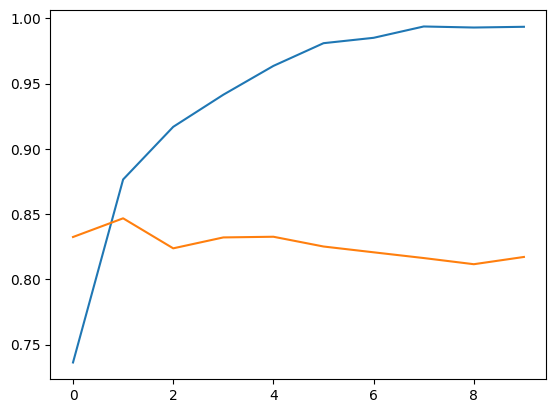

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])